In [1]:
import numpy as np
import pandas as pd
from model import ProbModel
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle

In [3]:
df = pd.read_csv('../../data/processed/20-24/dataset_clean_no-outliers.csv').drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [3]:
# realignment
df['speed'] = df['speed'][6:].reset_index(drop=True)
df['power'] = df['power'][:-6].reset_index(drop=True)

normalized = (df['power'] - df['power'].min()) / (df['power'].max() - df['power'].min()) # normalize
df['power'] = np.clip(normalized, 1e-15, 1 - 1e-15)

df.dropna(inplace=True)

In [4]:
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.2 * n)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].reset_index(drop=True)
val_df = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_df = df.iloc[train_size + val_size:].reset_index(drop=True)

print(train_df.shape)
print(train_df.columns)

(30662, 5)
Index(['datetime', 'speed', 'power', 'price', 'load'], dtype='object')


In [5]:
model = ProbModel(
    binning_method='equal_width',
    interval_params=1,
    spline_k=3,
    spline_s=0.5
)

In [6]:
model.fit(train_df['speed'], train_df['power'])
train_df['pred'] = model.predict(train_df['speed'])
val_df['pred'] = model.predict(val_df['speed'])
test_df['pred'] = model.predict(test_df['speed'])

mse = mean_squared_error(train_df['power'], train_df['pred'])
print(f"Train MSE: {mse}")

mse = mean_squared_error(val_df['power'], val_df['pred'])
print(f"Validation MSE: {mse}")

mse = mean_squared_error(test_df['power'], test_df['pred'])
print(f"Test MSE: {mse}")

Train MSE: 0.031773985788937406
Validation MSE: 0.04089550901394527
Test MSE: 0.03678987265924495


In [7]:
model.get_params()

{'binning_method': 'equal_width',
 'interval_params': 1,
 'spline_k': 3,
 'spline_s': 0.5,
 'smoothing_factor': 0.01,
 'drift_factor': 0.001,
 'reset_prev_w': 0.02}

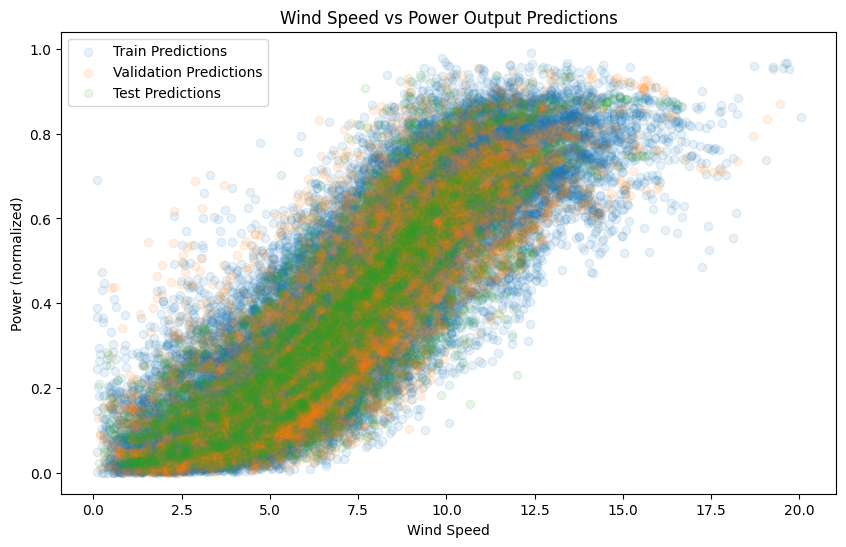

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(train_df['speed'], train_df['pred'], label='Train Predictions', alpha=0.1)
plt.scatter(val_df['speed'], val_df['pred'], label='Validation Predictions', alpha=0.1)
plt.scatter(test_df['speed'], test_df['pred'], label='Test Predictions', alpha=0.1)
plt.xlabel('Wind Speed')
plt.ylabel('Power (normalized)')
plt.title('Wind Speed vs Power Output Predictions')
plt.legend()
plt.show()

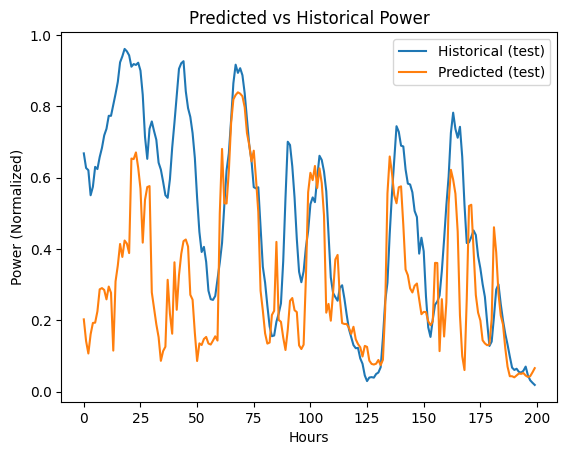

In [9]:
# plt.plot(train_df['power'][:200], label='Historical')
# plt.plot(train_df['pred'][:200], label='Predicted')

# plt.plot(val_df['power'][:200], label='Historical (val)')
# plt.plot(val_df['pred'][:200], label='Predicted (val)')

plt.plot(test_df['power'][0:200].reset_index(drop=True), label='Historical (test)')
plt.plot(test_df['pred'][0:200].reset_index(drop=True), label='Predicted (test)')

plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.title('Predicted vs Historical Power')
plt.legend()

In [10]:
a_spline = model.get_var('a_spline')
b_spline = model.get_var('b_spline')
lowers, uppers = model.get_var('intervals')

avg_speeds = []
for i in range(len(lowers)):
    lower = lowers[i]
    upper = uppers[i]
    avg_speed = (lower + upper) / 2
    avg_speeds.append(avg_speed)

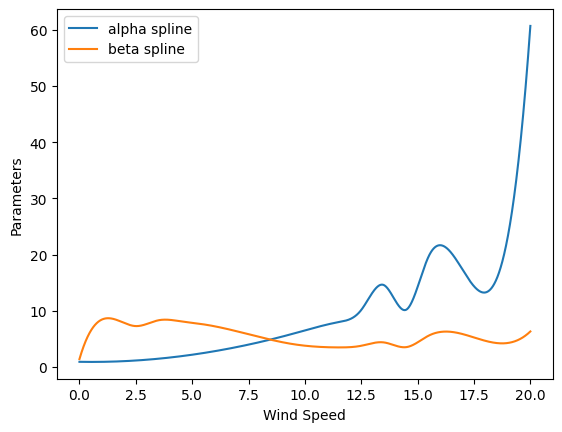

In [11]:
x = np.linspace(0, 20, 10000)
plt.plot(x, a_spline(x), label="alpha spline")
plt.plot(x, b_spline(x), label="beta spline")
plt.xlabel("Wind Speed")
plt.ylabel("Parameters")
plt.legend()

In [12]:
model.fit(train_df['speed'], train_df['power'])

# bayes

In [41]:
from skopt import BayesSearchCV

In [43]:
param_space = {
    'spline_k': [1, 2, 3, 4, 5],
    'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100, 250],
    'smoothing_factor': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2],
    'drift_factor': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05, 0.1]
}

In [45]:
opt = BayesSearchCV(
    ProbModel(
        binning_method='moving_window',
        interval_params=(1, 0.5),
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt2 = BayesSearchCV(
    ProbModel(
        binning_method='fixed',
        interval_params=[0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt3 = BayesSearchCV(
    ProbModel(
        binning_method='equal_freq',
        interval_params=100,
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt4 = BayesSearchCV(
    ProbModel(
        binning_method='equal_width',
        interval_params=0.5
    ),
    param_space,
    n_iter=50,
    cv=3
)

In [47]:
print("Fitting opt1...")
opt.fit(train_df['speed'], train_df['power'])
print("Fitting opt2...")
opt2.fit(train_df['speed'], train_df['power'])
print("Fitting opt3...")
opt3.fit(train_df['speed'], train_df['power'])
print("Fitting opt4...")
opt4.fit(train_df['speed'], train_df['power'])

Fitting opt1...
Fitting opt2...
Fitting opt3...
Fitting opt4...


BayesSearchCV(cv=3, estimator=<model.ProbModel object at 0x15c795ee0>,
              search_spaces={'drift_factor': [1e-05, 0.0001, 0.001, 0.01, 0.1],
                             'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05,
                                              0.1],
                             'smoothing_factor': [0.0001, 0.001, 0.01, 0.05,
                                                  0.1, 0.2],
                             'spline_k': [1, 2, 3, 4, 5],
                             'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100,
                                          250]})

In [52]:
print(opt.best_params_)
print(opt2.best_params_)
print(opt3.best_params_)
print(opt4.best_params_)

OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.001, 'smoothing_factor': 0.01, 'spline_k': 4, 'spline_s': 1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0.1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 2, 'spline_s': 0})


# Loading best_model pickle

In [1]:
import numpy as np
import pandas as pd
from model import ProbModel
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle
from scipy.spatial.distance import jensenshannon

In [2]:
with open('results/best_model.pkl', 'rb') as f:
    best = pickle.load(f)

In [3]:
# df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
# df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

# df = pd.read_csv('../../data/processed/dataset_14-23.csv')

df = pd.read_csv('wevalidate_data/EIA_930.csv')

# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

In [4]:
df

,datetime,power,npower,speed,nspeed
0,2018-07-01 05:00:00,0,0.000000,8.061592,0.379684
1,2018-07-01 06:00:00,0,0.000000,9.478211,0.447120
2,2018-07-01 07:00:00,0,0.000000,10.042563,0.473984
3,2018-07-01 08:00:00,50,0.485437,9.480452,0.447226
4,2018-07-01 09:00:00,55,0.533981,9.033495,0.425950
...,...,...,...,...,...
4406,2018-12-31 19:00:00,7,0.067961,4.305253,0.200872
4407,2018-12-31 20:00:00,1,0.009709,2.721040,0.125459
4408,2018-12-31 21:00:00,2,0.019417,2.019171,0.092047
4409,2018-12-31 22:00:00,0,0.000000,1.126299,0.049544


In [5]:
model = best['model']
npower = df['npower'].clip(lower=1e-15, upper=1 - 1e-15)
model.fit(df['speed'], npower)

In [6]:
npreds = model.predict(df['speed'])
# preds = np.array(npreds) * 244.5
preds = np.array(npreds) * 104.4

mse = mean_squared_error(df['npower'], npreds)
print("MSE:", mse)

mse = mean_squared_error(df['power'], preds)
print("MSE:", mse)

MSE: 0.10743970408323915
MSE: 1146.5462174149363


In [7]:
df['preds'] = preds
df['npreds'] = npreds

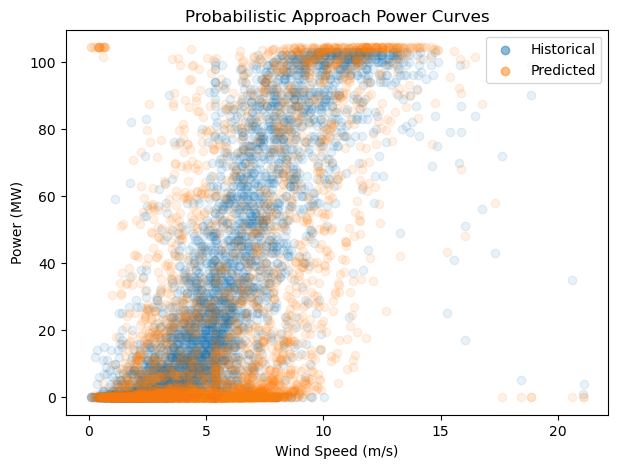

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(df['speed'], df['power'], alpha=0.1, label='Historical')
plt.scatter(df['speed'], preds, alpha=0.1, label='Predicted')

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Probabilistic Approach Power Curves')

leg = plt.legend()
for leg in leg.legend_handles:
    leg.set_alpha(0.5)

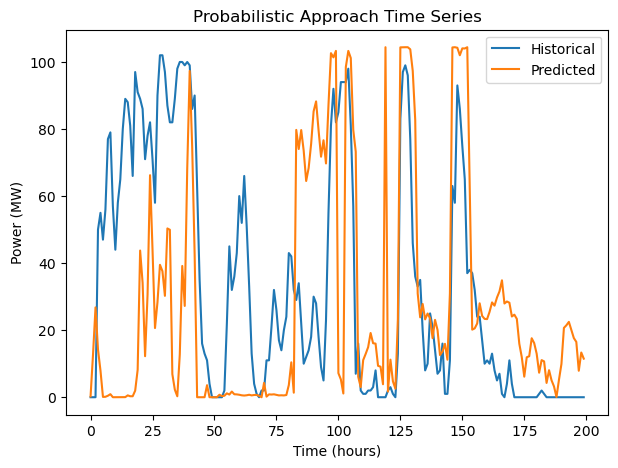

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(preds[:200], label='Predicted')
plt.title('Probabilistic Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

### comparing power curves

In [149]:
H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
H_pred, _, _ = np.histogram2d(df['speed'], preds, bins=50)

# normalize
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()

mse = np.mean((H_true_norm - H_pred_norm) ** 2)
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round(similarity * 100, 2)

# for density plot
vals_true = np.log(H_true.T)
vals_true[np.isneginf(vals_true)] = 0
vals_true = vals_true / vals_true.max()

vals_pred = np.log(H_pred.T)
vals_pred[np.isneginf(vals_pred)] = 0
vals_pred = vals_pred / vals_pred.max()

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_29864/165989337.py:14: RuntimeWarning: divide by zero encountered in log
  vals_true = np.log(H_true.T)
/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_29864/165989337.py:18: RuntimeWarning: divide by zero encountered in log
  vals_pred = np.log(H_pred.T)


In [150]:
print(f"MSE: {mse}")
print(f"JS Divergence: {js_div}")
print(f"Similarity: {similarity}")
print(f"Match Percentage: {match_percentage}%")

MSE: 2.618049426497315e-07
JS Divergence: 0.16936501498730552
Similarity: 0.8306349850126945
Match Percentage: 83.06%


Text(0.5, 0.98, 'Probabilistic Power Curve Density (Match: 83.06%)')

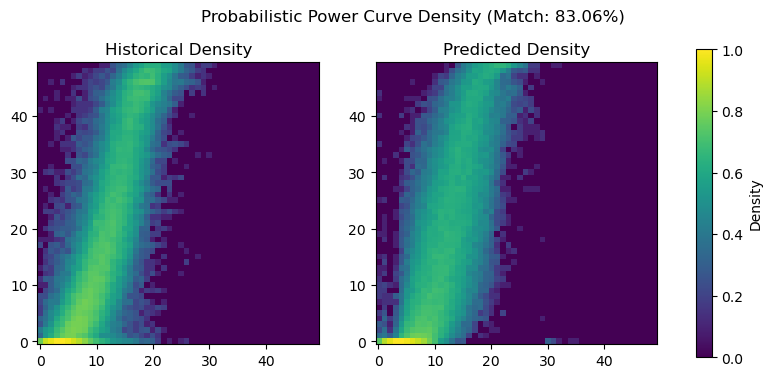

In [151]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(vals_true, origin='lower', cmap='viridis')
axs[0].set_title("Historical Density")

axs[1].imshow(vals_pred, origin='lower', cmap='viridis')
axs[1].set_title("Predicted Density")

cbar = fig.colorbar(axs[1].imshow(vals_pred, origin='lower', cmap='viridis'), ax=axs, orientation='vertical')
cbar.set_label('Density')
fig.suptitle(f"Probabilistic Power Curve Density (Match: {match_percentage}%)")

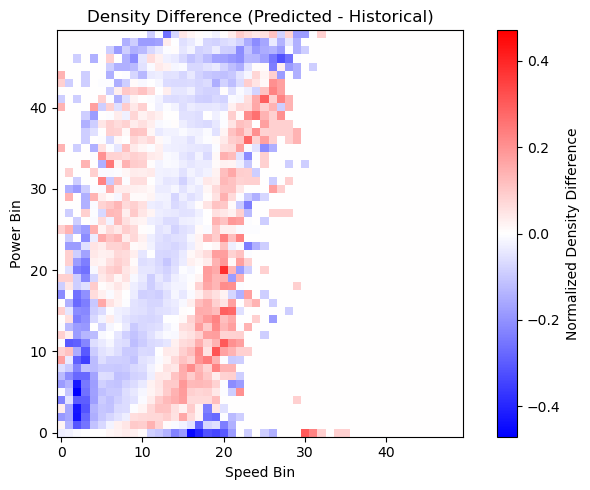

In [141]:
diff = vals_pred - vals_true

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
ax.set_title("Density Difference (Predicted - Historical)")
ax.set_xlabel("Speed Bin")
ax.set_ylabel("Power Bin")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Normalized Density Difference (Predicted - Historical)")
plt.tight_layout()
plt.show()

In [10]:
import sys
sys.path.append('../evaluation')
from evaluation import Metrics, Plot

Probabilistic Metrics:
RMSE: 0.3277799629068854
Bias: -0.1062112988679798
Cross Correlation: 0.5558981250932375
Similarity: 0.5626208820216858
RMS Steady: 97.3616047970599
RMS Loss: 80.80075426915528
RMS True: 46.85261987464643
RMS Predicted: 39.6318690544637


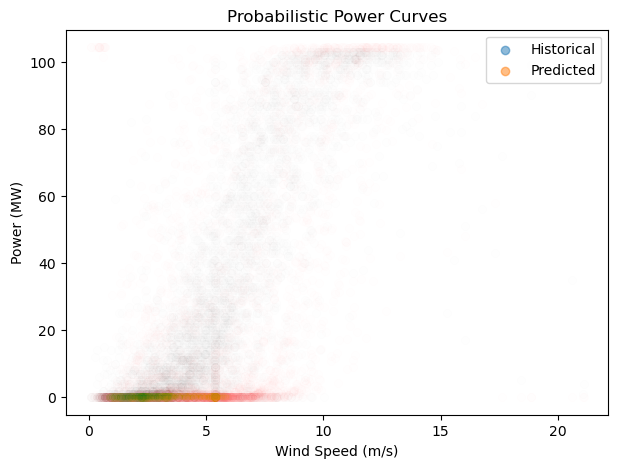

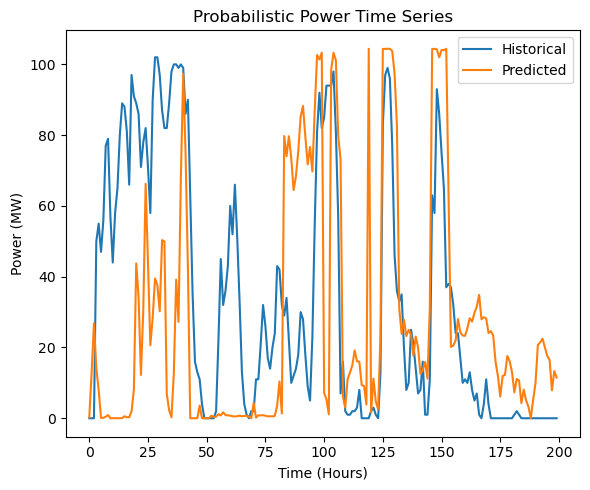

/Users/jessicayao/Documents/REU/wind-energy-forecasting/power_model/probabilistic/../evaluation/evaluation.py:119: RuntimeWarning: divide by zero encountered in log
  vals_true = np.log(H_true.T)
/Users/jessicayao/Documents/REU/wind-energy-forecasting/power_model/probabilistic/../evaluation/evaluation.py:122: RuntimeWarning: divide by zero encountered in log
  vals_pred = np.log(H_pred.T)


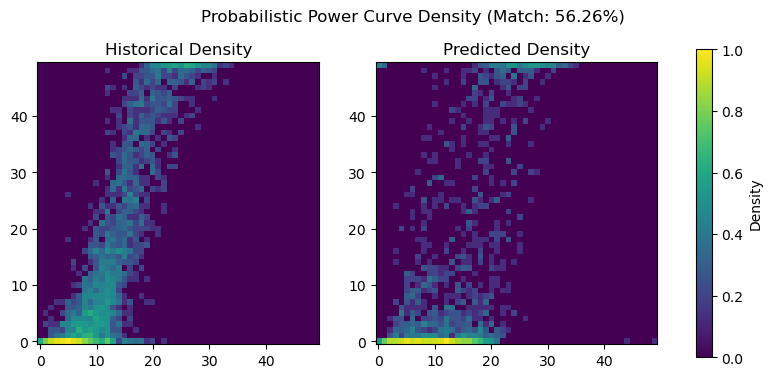

/Users/jessicayao/Documents/REU/wind-energy-forecasting/power_model/probabilistic/../evaluation/evaluation.py:147: RuntimeWarning: divide by zero encountered in log
  vals_true = np.log(H_true.T)
/Users/jessicayao/Documents/REU/wind-energy-forecasting/power_model/probabilistic/../evaluation/evaluation.py:150: RuntimeWarning: divide by zero encountered in log
  vals_pred = np.log(H_pred.T)


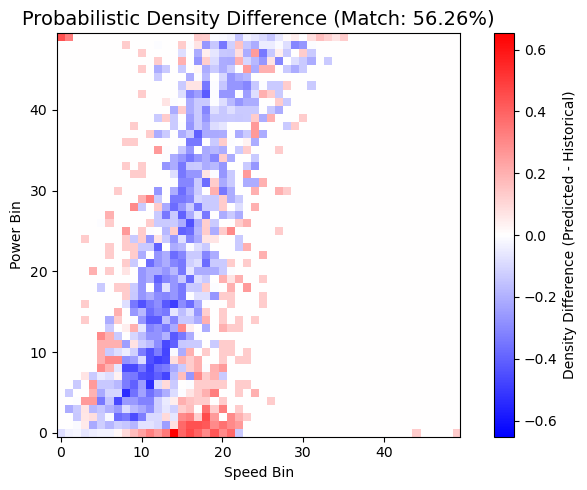

/Users/jessicayao/miniconda3/envs/dsu_app/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [11]:
trad_metrics = Metrics('Probabilistic', df['speed'], df['power'], df['preds'])
trad_plot = Plot('Probabilistic', df['speed'], df['power'], df['preds'])
trad_metrics.print_metrics()
trad_plot.plot_all()

## save csv for we-validate

In [31]:
from datetime import datetime, timedelta

In [32]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [ ]:
df

,time_stamp,speed,power,npower,nspeed,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,0.280607,145.092227,0.593424
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,0.243382,120.531092,0.492970
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,0.181116,71.752208,0.293465
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,0.108431,12.489751,0.051083
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.120886,22.720655,0.092927
...,...,...,...,...,...,...,...
82295,2023-12-31 19:00:00,10.002887,14.636,0.059927,0.298106,106.454807,0.435398
82296,2023-12-31 20:00:00,9.850973,5.243,0.021468,0.293574,102.914333,0.420918
82297,2023-12-31 21:00:00,9.078698,0.446,0.001826,0.270536,85.056663,0.347880
82298,2023-12-31 22:00:00,8.771991,0.195,0.000798,0.261387,79.220808,0.324011


In [34]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    # while len(time_stamps) < 34856:
    while len(time_stamps) < 82300:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

# time_stamp = generate_time_stamps(datetime(2018, 1, 1, 1, 0, 0))
time_stamp = generate_time_stamps(datetime(2014, 7, 30, 12, 0, 0))
df['time_stamp'] = time_stamp

In [35]:
df

,time_stamp,speed,power,npower,nspeed,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,0.280607,145.092227,0.593424
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,0.243382,120.531092,0.492970
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,0.181116,71.752208,0.293465
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,0.108431,12.489751,0.051083
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.120886,22.720655,0.092927
...,...,...,...,...,...,...,...
82295,2023-12-19 11:00:00,10.002887,14.636,0.059927,0.298106,106.454807,0.435398
82296,2023-12-19 12:00:00,9.850973,5.243,0.021468,0.293574,102.914333,0.420918
82297,2023-12-19 13:00:00,9.078698,0.446,0.001826,0.270536,85.056663,0.347880
82298,2023-12-19 14:00:00,8.771991,0.195,0.000798,0.261387,79.220808,0.324011


In [36]:
df.to_csv('results/prob_1423.csv', index=False)

# Testing on We-Validate's data

In [97]:
df = pd.read_csv('wevalidate_data/EIA_930.csv')
df['speed'] = df['speed'].fillna(df['speed'].mean())

In [100]:
with open('results/best_model.pkl', 'rb') as f:
    best = pickle.load(f)

In [101]:
model = best['model']
df['npower'] = df['npower'].clip(lower=1e-15, upper=1 - 1e-15)
model.fit(df['speed'], df['npower'])

In [111]:
npreds = model.predict(df['speed'])
preds = np.array(npreds) * 104.4

mse = mean_squared_error(df['npower'], npreds)
print("MSE:", mse)

mse = mean_squared_error(df['power'], preds)
print("MSE:", mse)

MSE: 0.09705047168995626
MSE: 1038.3778568464932


In [112]:
df['npreds'] = npreds
df['preds'] = preds

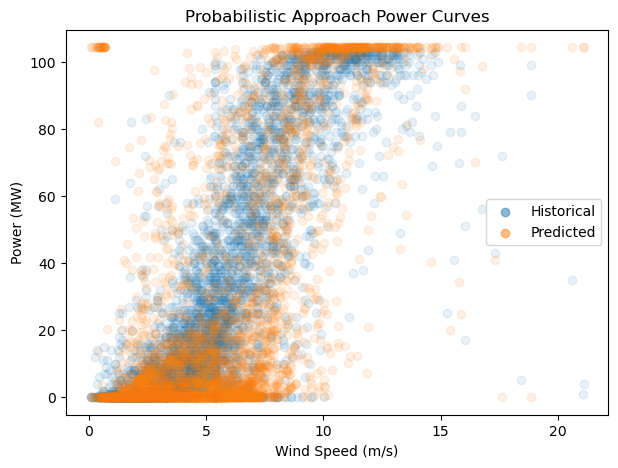

In [113]:
plt.figure(figsize=(7, 5))

plt.scatter(df['speed'], df['power'], alpha=0.1, label='Historical')
plt.scatter(df['speed'], preds, alpha=0.1, label='Predicted')

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Probabilistic Approach Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

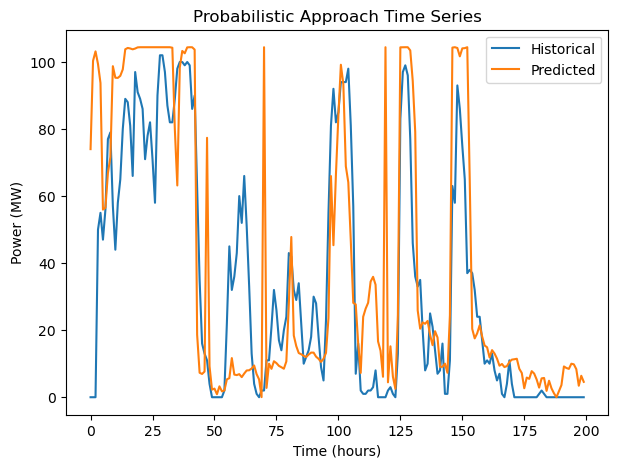

In [114]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(preds[:200], label='Predicted')
plt.title('Probabilistic Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

In [19]:
df

,datetime,speed,power,npower,nspeed
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,0.280607
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,0.243382
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,0.181116
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,0.108431
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.120886
...,...,...,...,...,...
82295,2023-12-31 19:00:00,10.002887,14.636,0.059927,0.298106
82296,2023-12-31 20:00:00,9.850973,5.243,0.021468,0.293574
82297,2023-12-31 21:00:00,9.078698,0.446,0.001826,0.270536
82298,2023-12-31 22:00:00,8.771991,0.195,0.000798,0.261387


In [116]:
H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
H_pred, _, _ = np.histogram2d(df['speed'], preds, bins=50)

# normalize
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()

mse = np.mean((H_true_norm - H_pred_norm) ** 2)
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round(similarity * 100, 2)

In [117]:
print(f"MSE: {mse}")
print(f"JS Divergence: {js_div}")
print(f"Similarity: {similarity}")
print(f"Match Percentage: {match_percentage}%")

MSE: 1.7558790519836102e-06
JS Divergence: 0.3990338966285804
Similarity: 0.6009661033714195
Match Percentage: 60.1%


Text(0.5, 1.0, 'Predicted Density')

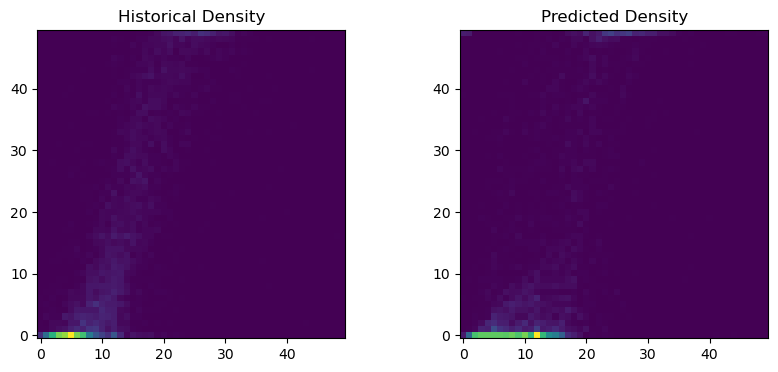

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(H_true_norm.T, origin='lower')
axs[0].set_title("Historical Density")

axs[1].imshow(H_pred_norm.T, origin='lower')
axs[1].set_title("Predicted Density")

In [120]:
df.to_csv('wevalidate_data/EIA_930_prob.csv', index=False)